# 12 - Reservation Experiment Playground

This notebook is meant for experiments. Change the parameter cell, run the notebook, then use the plotting helpers to inspect the result you care about.

The main dataframes created here are:

- `scenario_grid`: one row per scenario before simulation.
- `run_df`: one row per policy, scenario, seed, and `Q` with aggregate metrics.
- `class_df`: one row per class for each run.
- `score_df`: objective-function values for every run, including booked-slot utilization.
- `paired_objectives`: strict-reservation objective values matched to FCFS for the same scenario and seed.
- `difference_summary`: mean strict-minus-FCFS differences by scenario, `Q`, and objective parameters.
- `best_q`: the best `Q` found for each scenario and objective setting.
- `rule_df` and `rule_summary`: constraint-style checks.

## Setup

Run this once. It finds the repository root and imports the simulation code.

In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False


def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "simulation" / "engine.py").exists() and (
            candidate / "analysis" / "metrics.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")


REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import aggregate_result_row, class_result_rows
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import PatientClassParams, SimulationConfig, ThresholdRule

plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

## Parameters

This is the main cell to edit.

Useful starting points:

- For quick checks, keep `SEEDS` short.
- For final plots, use `SEEDS = list(range(5101, 5131))`.
- `DEMAND_GRID_MODE = "equal_rates"` is the current default: each scenario has `lambda_1 = lambda_2`.
- If you change simulation parameters, a new cache key is created automatically.
- The default objective is `booked_slot_utilization`, meaning booked appointment slots divided by available slots.

In [2]:
STRICT_POLICY = "Strict C1 reservation"
FCFS_POLICY = "Pooled FCFS"

BASE_CONFIG = {
    "slots_per_day": 32,
    "horizon_days": 14,
    "burn_in_days": 30,
    "measure_days": 365,
    "cooldown_days": 14,
    "reserved_class_id": 1,
}

Q_VALUES = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 32]
SEEDS = list(range(5101, 5106))

# Demand options. Pick one mode below.
DEMAND_GRID_MODE = "equal_rates"  # "equal_rates", "total_and_share", or "custom_pairs"
EQUAL_CLASS_ARRIVAL_VALUES = [20, 25, 35, 50]
TOTAL_ARRIVAL_VALUES = [40, 50, 70, 100]
CLASS_1_SHARE_VALUES = [0.25, 0.50, 0.75]
CUSTOM_LAMBDA_PAIRS = [(25, 25), (35, 25), (25, 35), (50, 50)]

SCENARIO_TYPES_TO_RUN = [
    "symmetric_baseline",
    "class_1_advantaged",
    "class_1_disadvantaged",
]

CLASS_1_WEIGHTS = [1.0, 1.25, 1.5, 2.0, 3.0]
CLASS_2_WEIGHT = 1.0
SLOT_COSTS = [0.0, 0.01, 0.02, 0.05, 0.10]
WAIT_PENALTIES = [0.0, 0.02, 0.05, 0.10]

UTILIZATION_FLOORS = [0.50, 0.75, 0.85, 0.90]
SERVED_RATE_FLOORS = [0.45, 0.55, 0.65, 0.70]
CLASS_UTILIZATION_GAP_LIMITS = [0.10, 0.20, 0.30]

MAIN_SCENARIO_TYPE = "symmetric_baseline"
MAIN_SCORE_NAME = "booked_slot_utilization"
MAIN_CLASS_1_WEIGHT = 1.5
MAIN_SLOT_COST = 0.05
MAIN_WAIT_PENALTY = 0.0
MAIN_CLASS_ID = 1

CACHE_ROOT = REPO_DIR / "notebooks" / "temp" / "reservation_playground_cache"
FORCE_RERUN_SIMULATION = False
SAVE_CACHE = True

pd.Series(
    {
        "q_values": Q_VALUES,
        "seeds": f"{SEEDS[0]}-{SEEDS[-1]} ({len(SEEDS)} seeds)",
        "demand_grid_mode": DEMAND_GRID_MODE,
        "equal_class_arrival_values": EQUAL_CLASS_ARRIVAL_VALUES,
        "total_arrival_values": TOTAL_ARRIVAL_VALUES,
        "class_1_share_values": CLASS_1_SHARE_VALUES,
        "custom_lambda_pairs": CUSTOM_LAMBDA_PAIRS,
        "scenario_types": SCENARIO_TYPES_TO_RUN,
        "class_1_weights": CLASS_1_WEIGHTS,
        "slot_costs": SLOT_COSTS,
        "wait_penalties": WAIT_PENALTIES,
        "slots_per_day": BASE_CONFIG["slots_per_day"],
        "horizon_days": BASE_CONFIG["horizon_days"],
    },
    name="value",
).to_frame()

,value
q_values,"[0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 32]"
seeds,5101-5105 (5 seeds)
demand_grid_mode,equal_rates
equal_class_arrival_values,"[20, 25, 35, 50]"
total_arrival_values,"[40, 50, 70, 100]"
class_1_share_values,"[0.25, 0.5, 0.75]"
custom_lambda_pairs,"[(25, 25), (35, 25), (25, 35), (50, 50)]"
scenario_types,"[symmetric_baseline, class_1_advantaged, class..."
class_1_weights,"[1.0, 1.25, 1.5, 2.0, 3.0]"
slot_costs,"[0.0, 0.01, 0.02, 0.05, 0.1]"


## Behavior Regimes

Edit these probabilities directly if you want a different behavioral story. Each class has:

- an arrival rate from the demand grid,
- a cancellation probability,
- a balking rule based on offered delay,
- a no-show rule based on offered delay.

The `threshold` rule means: use `low` probability up to that delay, then `high` probability after it.

In [3]:
BEHAVIOR_PRESETS = {
    "symmetric_baseline": {
        1: {
            "cancel_prob": 0.10,
            "balk_prob": {"threshold": 9, "low": 0.00, "high": 0.50},
            "no_show_prob": {"threshold": 6, "low": 0.00, "high": 0.30},
        },
        2: {
            "cancel_prob": 0.10,
            "balk_prob": {"threshold": 9, "low": 0.00, "high": 0.50},
            "no_show_prob": {"threshold": 6, "low": 0.00, "high": 0.30},
        },
    },
    "class_1_advantaged": {
        1: {
            "cancel_prob": 0.05,
            "balk_prob": {"threshold": 12, "low": 0.00, "high": 0.35},
            "no_show_prob": {"threshold": 9, "low": 0.00, "high": 0.20},
        },
        2: {
            "cancel_prob": 0.15,
            "balk_prob": {"threshold": 7, "low": 0.02, "high": 0.65},
            "no_show_prob": {"threshold": 4, "low": 0.05, "high": 0.40},
        },
    },
    "class_1_disadvantaged": {
        1: {
            "cancel_prob": 0.15,
            "balk_prob": {"threshold": 7, "low": 0.02, "high": 0.65},
            "no_show_prob": {"threshold": 4, "low": 0.05, "high": 0.40},
        },
        2: {
            "cancel_prob": 0.05,
            "balk_prob": {"threshold": 12, "low": 0.00, "high": 0.35},
            "no_show_prob": {"threshold": 9, "low": 0.00, "high": 0.20},
        },
    },
}

behavior_table = []
for scenario_type, class_params in BEHAVIOR_PRESETS.items():
    for class_id, params in class_params.items():
        behavior_table.append(
            {
                "scenario_type": scenario_type,
                "class_id": class_id,
                "cancel_prob": params["cancel_prob"],
                "balk_threshold": params["balk_prob"]["threshold"],
                "balk_low": params["balk_prob"]["low"],
                "balk_high": params["balk_prob"]["high"],
                "no_show_threshold": params["no_show_prob"]["threshold"],
                "no_show_low": params["no_show_prob"]["low"],
                "no_show_high": params["no_show_prob"]["high"],
            }
        )

pd.DataFrame(behavior_table)

,scenario_type,class_id,cancel_prob,balk_threshold,balk_low,balk_high,no_show_threshold,no_show_low,no_show_high
0,symmetric_baseline,1,0.10,9,0.00,0.50,6,0.00,0.3
1,symmetric_baseline,2,0.10,9,0.00,0.50,6,0.00,0.3
2,class_1_advantaged,1,0.05,12,0.00,0.35,9,0.00,0.2
3,class_1_advantaged,2,0.15,7,0.02,0.65,4,0.05,0.4
4,class_1_disadvantaged,1,0.15,7,0.02,0.65,4,0.05,0.4
5,class_1_disadvantaged,2,0.05,12,0.00,0.35,9,0.00,0.2


## Scenario Grid

This turns the parameter cell into a table of scenarios. Check this table before running the simulation.

In [4]:
def make_scenario_grid() -> pd.DataFrame:
    rows = []
    scenario_counter = 0

    for scenario_type in SCENARIO_TYPES_TO_RUN:
        if scenario_type not in BEHAVIOR_PRESETS:
            raise KeyError(f"Unknown scenario_type: {scenario_type}")

        if DEMAND_GRID_MODE == "equal_rates":
            demand_rows = [
                {
                    "demand_label": f"lambda1=lambda2={value:g}",
                    "class_arrival_rate": float(value),
                    "lambda_1": float(value),
                    "lambda_2": float(value),
                }
                for value in EQUAL_CLASS_ARRIVAL_VALUES
            ]
        elif DEMAND_GRID_MODE == "total_and_share":
            demand_rows = []
            for total in TOTAL_ARRIVAL_VALUES:
                for share in CLASS_1_SHARE_VALUES:
                    demand_rows.append(
                        {
                            "demand_label": f"total={total:g}, share1={share:.2f}",
                            "class_arrival_rate": np.nan,
                            "lambda_1": float(total * share),
                            "lambda_2": float(total * (1 - share)),
                        }
                    )
        elif DEMAND_GRID_MODE == "custom_pairs":
            demand_rows = [
                {
                    "demand_label": f"lambda1={lambda_1:g}, lambda2={lambda_2:g}",
                    "class_arrival_rate": float(lambda_1) if lambda_1 == lambda_2 else np.nan,
                    "lambda_1": float(lambda_1),
                    "lambda_2": float(lambda_2),
                }
                for lambda_1, lambda_2 in CUSTOM_LAMBDA_PAIRS
            ]
        else:
            raise ValueError("DEMAND_GRID_MODE must be 'equal_rates', 'total_and_share', or 'custom_pairs'.")

        for demand in demand_rows:
            scenario_counter += 1
            lambda_total = demand["lambda_1"] + demand["lambda_2"]
            rows.append(
                {
                    "scenario_id": f"s{scenario_counter:03d}",
                    "scenario_type": scenario_type,
                    **demand,
                    "lambda_total": lambda_total,
                    "class_1_share": demand["lambda_1"] / lambda_total if lambda_total else 0.0,
                }
            )

    return pd.DataFrame(rows)


scenario_grid = make_scenario_grid()
display(scenario_grid)
print(f"Scenarios: {len(scenario_grid)}")

,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share
0,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5
1,s002,symmetric_baseline,lambda1=lambda2=25,25.0,25.0,25.0,50.0,0.5
2,s003,symmetric_baseline,lambda1=lambda2=35,35.0,35.0,35.0,70.0,0.5
3,s004,symmetric_baseline,lambda1=lambda2=50,50.0,50.0,50.0,100.0,0.5
4,s005,class_1_advantaged,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5
5,s006,class_1_advantaged,lambda1=lambda2=25,25.0,25.0,25.0,50.0,0.5
6,s007,class_1_advantaged,lambda1=lambda2=35,35.0,35.0,35.0,70.0,0.5
7,s008,class_1_advantaged,lambda1=lambda2=50,50.0,50.0,50.0,100.0,0.5
8,s009,class_1_disadvantaged,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5
9,s010,class_1_disadvantaged,lambda1=lambda2=25,25.0,25.0,25.0,50.0,0.5


Scenarios: 12


## Simulation Helpers

These functions convert scenario rows into simulation configs and collect the results into dataframes.

In [5]:
def safe_divide(numerator: float, denominator: float) -> float:
    return numerator / denominator if denominator else 0.0


def build_config(scenario: pd.Series, *, q: int, seed: int | None, policy: str) -> SimulationConfig:
    behavior = BEHAVIOR_PRESETS[scenario["scenario_type"]]
    classes = {}
    for class_id, lambda_value in [(1, scenario["lambda_1"]), (2, scenario["lambda_2"])]:
        params = behavior[class_id]
        classes[class_id] = PatientClassParams(
            class_id=class_id,
            lambda_per_day=float(lambda_value),
            balk_prob=ThresholdRule(**params["balk_prob"]),
            cancel_prob=float(params["cancel_prob"]),
            no_show_prob=ThresholdRule(**params["no_show_prob"]),
            value=1.0,
        )

    reserved_slots = int(q) if policy == STRICT_POLICY else 0
    return SimulationConfig(
        slots_per_day=int(BASE_CONFIG["slots_per_day"]),
        horizon_days=int(BASE_CONFIG["horizon_days"]),
        burn_in_days=int(BASE_CONFIG["burn_in_days"]),
        measure_days=int(BASE_CONFIG["measure_days"]),
        cooldown_days=int(BASE_CONFIG["cooldown_days"]),
        classes=classes,
        seed=seed,
        reserved_class_id=BASE_CONFIG["reserved_class_id"] if reserved_slots > 0 else None,
        reserved_slots_per_day=reserved_slots,
    )


def summarize_run(result, config: SimulationConfig, fixed_values: dict) -> tuple[dict, list[dict]]:
    aggregate = aggregate_result_row(result, fixed_values)
    class_rows = class_result_rows(result, fixed_values)
    class_by_id = pd.DataFrame(class_rows).set_index("class_id")
    c1 = class_by_id.loc[1]
    c2 = class_by_id.loc[2]
    total_arrivals = aggregate["total_arrivals"]

    aggregate_row = {
        **aggregate,
        "slots_per_day": config.slots_per_day,
        "horizon_days": config.horizon_days,
        "served_rate": safe_divide(aggregate["total_served"], total_arrivals),
        "lost_rate": 1.0 - safe_divide(aggregate["total_served"], total_arrivals),
        "balked_rate": safe_divide(aggregate["total_balked"], total_arrivals),
        "no_offer_rate": safe_divide(aggregate["total_no_offer"], total_arrivals),
        "canceled_rate": safe_divide(aggregate["total_canceled"], total_arrivals),
        "no_show_rate": safe_divide(aggregate["total_no_show"], total_arrivals),
        "unresolved_booked_rate": safe_divide(aggregate["total_unresolved_booked"], total_arrivals),
        "class_1_arrivals": c1["arrivals"],
        "class_2_arrivals": c2["arrivals"],
        "class_1_served": c1["served"],
        "class_2_served": c2["served"],
        "class_1_offered": c1["offered"],
        "class_2_offered": c2["offered"],
        "class_1_served_rate": c1["percent_serviced"],
        "class_2_served_rate": c2["percent_serviced"],
        "min_class_served_rate": min(c1["percent_serviced"], c2["percent_serviced"]),
        "class_1_slot_utilization": c1["slot_utilization"],
        "class_2_slot_utilization": c2["slot_utilization"],
        "class_utilization_gap": abs(c1["slot_utilization"] - c2["slot_utilization"]),
        "class_1_booked_slot_utilization": c1["booked_slot_utilization"],
        "class_2_booked_slot_utilization": c2["booked_slot_utilization"],
        "class_booked_slot_utilization_gap": abs(c1["booked_slot_utilization"] - c2["booked_slot_utilization"]),
        "class_1_total_offered_delay": c1["total_offered_booking_delay"],
        "class_2_total_offered_delay": c2["total_offered_booking_delay"],
    }

    enriched_class_rows = []
    for row in class_rows:
        arrivals = row["arrivals"]
        unresolved_booked = row["booked"] - row["canceled"] - row["no_show"] - row["served"]
        enriched_class_rows.append(
            {
                **row,
                "served_rate": row["percent_serviced"],
                "unresolved_booked": unresolved_booked,
                "lost_rate": 1.0 - row["percent_serviced"],
                "balked_rate": safe_divide(row["balked"], arrivals),
                "no_offer_rate": safe_divide(row["no_offer"], arrivals),
                "canceled_rate": safe_divide(row["canceled"], arrivals),
                "no_show_rate": safe_divide(row["no_show"], arrivals),
                "unresolved_booked_rate": safe_divide(unresolved_booked, arrivals),
            }
        )

    return aggregate_row, enriched_class_rows


def validate_accounting(run_df: pd.DataFrame, class_df: pd.DataFrame, tol: float = 1e-9) -> None:
    aggregate_partition = (
        run_df["total_served"]
        + run_df["total_balked"]
        + run_df["total_no_offer"]
        + run_df["total_canceled"]
        + run_df["total_no_show"]
        + run_df["total_unresolved_booked"]
    )
    if (aggregate_partition - run_df["total_arrivals"]).abs().max() > tol:
        raise AssertionError("Aggregate outcomes do not partition arrivals.")

    class_partition = (
        class_df["served"]
        + class_df["balked"]
        + class_df["no_offer"]
        + class_df["canceled"]
        + class_df["no_show"]
        + class_df["unresolved_booked"]
    )
    if (class_partition - class_df["arrivals"]).abs().max() > tol:
        raise AssertionError("Class outcomes do not partition arrivals.")


def run_policy_grid(scenarios: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    aggregate_rows = []
    class_rows = []
    tasks = list(scenarios.iterrows())

    for _, scenario in tqdm(tasks, desc="scenario"):
        scenario_metadata = scenario.to_dict()
        for seed in SEEDS:
            fcfs_config = build_config(scenario, q=0, seed=int(seed), policy=FCFS_POLICY)
            fcfs_result = ClinicAppointmentSimulation(fcfs_config).run()
            fixed = {**scenario_metadata, "policy": FCFS_POLICY, "seed": int(seed), "Q": 0}
            aggregate_row, class_result = summarize_run(fcfs_result, fcfs_config, fixed)
            aggregate_rows.append(aggregate_row)
            class_rows.extend(class_result)

            for q in Q_VALUES:
                strict_config = build_config(scenario, q=int(q), seed=int(seed), policy=STRICT_POLICY)
                strict_result = ClinicAppointmentSimulation(strict_config).run()
                fixed = {**scenario_metadata, "policy": STRICT_POLICY, "seed": int(seed), "Q": int(q)}
                aggregate_row, class_result = summarize_run(strict_result, strict_config, fixed)
                aggregate_rows.append(aggregate_row)
                class_rows.extend(class_result)

    run_df = pd.DataFrame(aggregate_rows)
    class_df = pd.DataFrame(class_rows)
    validate_accounting(run_df, class_df)
    return run_df, class_df

## Run Or Load Data

The simulation cache depends on simulation parameters, not on objective weights. You can change `CLASS_1_WEIGHTS`, `SLOT_COSTS`, or plotting filters without rerunning the simulation.

Set `FORCE_RERUN_SIMULATION = True` if you want to ignore the cache.

In [6]:
def stable_json(data: dict) -> str:
    return json.dumps(data, sort_keys=True, default=str)


def selected_behavior_params() -> dict:
    return {name: BEHAVIOR_PRESETS[name] for name in SCENARIO_TYPES_TO_RUN}


SIMULATION_PARAMS = {
    "cache_schema_version": "booked_slot_utilization_v1",
    "base_config": BASE_CONFIG,
    "q_values": Q_VALUES,
    "seeds": SEEDS,
    "demand_grid_mode": DEMAND_GRID_MODE,
    "equal_class_arrival_values": EQUAL_CLASS_ARRIVAL_VALUES,
    "total_arrival_values": TOTAL_ARRIVAL_VALUES,
    "class_1_share_values": CLASS_1_SHARE_VALUES,
    "custom_lambda_pairs": CUSTOM_LAMBDA_PAIRS,
    "scenario_types_to_run": SCENARIO_TYPES_TO_RUN,
    "behavior_presets": selected_behavior_params(),
}
SIMULATION_CACHE_KEY = hashlib.sha256(stable_json(SIMULATION_PARAMS).encode("utf-8")).hexdigest()[:12]
CACHE_DIR = CACHE_ROOT / SIMULATION_CACHE_KEY
RUN_CACHE_PATH = CACHE_DIR / "run_df.pkl"
CLASS_CACHE_PATH = CACHE_DIR / "class_df.pkl"
PARAMS_CACHE_PATH = CACHE_DIR / "simulation_params.json"

if RUN_CACHE_PATH.exists() and CLASS_CACHE_PATH.exists() and not FORCE_RERUN_SIMULATION:
    run_df = pd.read_pickle(RUN_CACHE_PATH)
    class_df = pd.read_pickle(CLASS_CACHE_PATH)
    print(f"Loaded cached simulation data from {CACHE_DIR}")
else:
    run_df, class_df = run_policy_grid(scenario_grid)
    if SAVE_CACHE:
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        run_df.to_pickle(RUN_CACHE_PATH)
        class_df.to_pickle(CLASS_CACHE_PATH)
        PARAMS_CACHE_PATH.write_text(stable_json(SIMULATION_PARAMS), encoding="utf-8")
        print(f"Saved simulation data to {CACHE_DIR}")

validate_accounting(run_df, class_df)
print(f"Aggregate rows: {len(run_df):,}")
print(f"Class rows: {len(class_df):,}")
print(f"Cache key: {SIMULATION_CACHE_KEY}")
display(run_df.head())
display(class_df.head())

Loaded cached simulation data from /Users/alexandresepulvedadedietrich/CUIMC-Appointment-Simulation/notebooks/temp/reservation_playground_cache/92a74cbf5416
Aggregate rows: 780
Class rows: 1,560
Cache key: 92a74cbf5416


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,policy,seed,Q,average_utilization,booked_slot_utilization,overall_percent_serviced,total_booked_slots,total_served_slots,total_no_show_slots,total_served,total_value,mean_accepted_booking_delay,mean_offered_booking_delay,overall_balking_rate,total_arrivals,total_booked,total_offered,total_balked,total_no_offer,total_canceled,total_no_show,total_unresolved_booked,slots_per_day,horizon_days,served_rate,lost_rate,balked_rate,no_offer_rate,canceled_rate,no_show_rate,unresolved_booked_rate,class_1_arrivals,class_2_arrivals,class_1_served,class_2_served,class_1_offered,class_2_offered,class_1_served_rate,class_2_served_rate,min_class_served_rate,class_1_slot_utilization,class_2_slot_utilization,class_utilization_gap,class_1_booked_slot_utilization,class_2_booked_slot_utilization,class_booked_slot_utilization_gap,class_1_total_offered_delay,class_2_total_offered_delay
0,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0
1,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0
2,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,2,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5949,5783,7360,7242,0.808288,0.798536,0.798536,0.509332,0.495120,0.014212,0.509332,0.495120,0.014212,22786.0,22405.0
3,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,4,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5954,5778,7360,7242,0.808967,0.797846,0.797846,0.509760,0.494692,0.015068,0.509760,0.494692,0.015068,22749.0,22442.0
4,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,6,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5956,5776,7360,7242,0.809239,0.797570,0.797570,0.509932,0.494521,0.015411,0.509932,0.494521,0.015411,22713.0,22478.0


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,policy,seed,Q,class_id,arrivals,booked,balked,offered,no_offer,canceled,no_show,served,mean_accepted_booking_delay,mean_offered_booking_delay,percent_serviced,slot_utilization,booked_slot_utilization,balking_rate,total_booking_delay,total_offered_booking_delay,served_rate,unresolved_booked,lost_rate,balked_rate,no_offer_rate,canceled_rate,no_show_rate,unresolved_booked_rate
0,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1,7360,7360,0,7360,0,1412,0,5948,3.097826,3.097826,0.808152,0.509247,0.509247,0.0,22800.0,22800.0,0.808152,0,0.191848,0.0,0.0,0.191848,0.0,0.0
1,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,2,7242,7242,0,7242,0,1458,0,5784,3.091825,3.091825,0.798674,0.495205,0.495205,0.0,22391.0,22391.0,0.798674,0,0.201326,0.0,0.0,0.201326,0.0,0.0
2,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,0,1,7360,7360,0,7360,0,1412,0,5948,3.097826,3.097826,0.808152,0.509247,0.509247,0.0,22800.0,22800.0,0.808152,0,0.191848,0.0,0.0,0.191848,0.0,0.0
3,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,0,2,7242,7242,0,7242,0,1458,0,5784,3.091825,3.091825,0.798674,0.495205,0.495205,0.0,22391.0,22391.0,0.798674,0,0.201326,0.0,0.0,0.201326,0.0,0.0
4,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Strict C1 reservation,5101,2,1,7360,7360,0,7360,0,1411,0,5949,3.095924,3.095924,0.808288,0.509332,0.509332,0.0,22786.0,22786.0,0.808288,0,0.191712,0.0,0.0,0.191712,0.0,0.0


## Data Dictionary

Use these tables to see what columns are available.

In [7]:
def dataframe_dictionary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dataframe": name,
            "column": df.columns,
            "dtype": [str(dtype) for dtype in df.dtypes],
            "non_null": [df[column].notna().sum() for column in df.columns],
            "example": [df[column].dropna().iloc[0] if df[column].notna().any() else None for column in df.columns],
        }
    )


data_dictionary = pd.concat(
    [
        dataframe_dictionary(scenario_grid, "scenario_grid"),
        dataframe_dictionary(run_df, "run_df"),
        dataframe_dictionary(class_df, "class_df"),
    ],
    ignore_index=True,
)
display(data_dictionary)

,dataframe,column,dtype,non_null,example
0,scenario_grid,scenario_id,object,12,s001
1,scenario_grid,scenario_type,object,12,symmetric_baseline
2,scenario_grid,demand_label,object,12,lambda1=lambda2=20
3,scenario_grid,class_arrival_rate,float64,12,20.0
4,scenario_grid,lambda_1,float64,12,20.0
...,...,...,...,...,...
95,class_df,balked_rate,float64,1560,0.0
96,class_df,no_offer_rate,float64,1560,0.0
97,class_df,canceled_rate,float64,1560,0.191848
98,class_df,no_show_rate,float64,1560,0.0


## Objective Functions And Constraints

These are notebook-local. Edit or add functions here when you want to test a new objective. The default capacity objective is booked-slot utilization: booked appointment slots divided by available slots.

The main capacity score is:

$$
\rho^{\mathrm{booked}}
=
\frac{\mathrm{booked\ slots\ on\ service\ days}}{S\times\mathrm{measured\ days}}.
$$

For class-weighted capacity scores, the playground uses:

$$
U_{\mathrm{booked}}(w_1,w_2)=w_1\rho_1^{\mathrm{booked}}+w_2\rho_2^{\mathrm{booked}}.
$$

The net booked-slot score subtracts the configured protected share:

$$
U_{\mathrm{net\ booked}}=U_{\mathrm{booked}}-c\frac{Q}{S}.
$$


In [8]:
def weighted_mean_offered_delay(row: pd.Series, class_1_weight: float, class_2_weight: float = CLASS_2_WEIGHT) -> float:
    weighted_delay = (
        class_1_weight * row["class_1_total_offered_delay"]
        + class_2_weight * row["class_2_total_offered_delay"]
    )
    weighted_offered = (
        class_1_weight * row["class_1_offered"]
        + class_2_weight * row["class_2_offered"]
    )
    return safe_divide(weighted_delay, weighted_offered)


def score_rows_for_run(row: pd.Series) -> list[dict]:
    rows = []
    q_share = safe_divide(row["Q"], row["slots_per_day"])

    rows.append(
        {
            **row.to_dict(),
            "score_name": "served_rate",
            "class_1_weight": 1.0,
            "slot_cost": 0.0,
            "wait_penalty": 0.0,
            "score_value": row["served_rate"],
        }
    )
    rows.append(
        {
            **row.to_dict(),
            "score_name": "booked_slot_utilization",
            "class_1_weight": 1.0,
            "slot_cost": 0.0,
            "wait_penalty": 0.0,
            "score_value": row["booked_slot_utilization"],
        }
    )

    for weight in CLASS_1_WEIGHTS:
        weighted_served_rate = safe_divide(
            weight * row["class_1_served"] + CLASS_2_WEIGHT * row["class_2_served"],
            weight * row["class_1_arrivals"] + CLASS_2_WEIGHT * row["class_2_arrivals"],
        )
        weighted_attended_slot_score = weight * row["class_1_slot_utilization"] + CLASS_2_WEIGHT * row["class_2_slot_utilization"]
        weighted_booked_slot_score = (
            weight * row["class_1_booked_slot_utilization"]
            + CLASS_2_WEIGHT * row["class_2_booked_slot_utilization"]
        )
        weighted_delay = weighted_mean_offered_delay(row, weight)

        rows.append(
            {
                **row.to_dict(),
                "score_name": "weighted_served_rate",
                "class_1_weight": weight,
                "slot_cost": 0.0,
                "wait_penalty": 0.0,
                "score_value": weighted_served_rate,
            }
        )
        rows.append(
            {
                **row.to_dict(),
                "score_name": "weighted_attended_slot_score",
                "class_1_weight": weight,
                "slot_cost": 0.0,
                "wait_penalty": 0.0,
                "score_value": weighted_attended_slot_score,
            }
        )
        rows.append(
            {
                **row.to_dict(),
                "score_name": "weighted_booked_slot_score",
                "class_1_weight": weight,
                "slot_cost": 0.0,
                "wait_penalty": 0.0,
                "score_value": weighted_booked_slot_score,
            }
        )

        for slot_cost in SLOT_COSTS:
            rows.append(
                {
                    **row.to_dict(),
                    "score_name": "net_priority_score",
                    "class_1_weight": weight,
                    "slot_cost": slot_cost,
                    "wait_penalty": 0.0,
                    "score_value": weighted_served_rate - slot_cost * q_share,
                }
            )
            rows.append(
                {
                    **row.to_dict(),
                    "score_name": "net_booked_slot_score",
                    "class_1_weight": weight,
                    "slot_cost": slot_cost,
                    "wait_penalty": 0.0,
                    "score_value": weighted_booked_slot_score - slot_cost * q_share,
                }
            )

            for wait_penalty in WAIT_PENALTIES:
                delay_cost = wait_penalty * safe_divide(weighted_delay, row["horizon_days"])
                rows.append(
                    {
                        **row.to_dict(),
                        "score_name": "wait_adjusted_booked_slot_score",
                        "class_1_weight": weight,
                        "slot_cost": slot_cost,
                        "wait_penalty": wait_penalty,
                        "score_value": weighted_booked_slot_score - slot_cost * q_share - delay_cost,
                    }
                )

    return rows


def rule_rows_for_run(row: pd.Series) -> list[dict]:
    rows = []
    for utilization_floor in UTILIZATION_FLOORS:
        for served_floor in SERVED_RATE_FLOORS:
            for gap_limit in CLASS_UTILIZATION_GAP_LIMITS:
                passes_rules = (
                    row["booked_slot_utilization"] >= utilization_floor
                    and row["min_class_served_rate"] >= served_floor
                    and row["class_utilization_gap"] <= gap_limit
                )
                rows.append(
                    {
                        **row.to_dict(),
                        "utilization_floor": utilization_floor,
                        "served_rate_floor": served_floor,
                        "class_utilization_gap_limit": gap_limit,
                        "passes_rules": passes_rules,
                        "utilization_if_rules_pass": row["booked_slot_utilization"] if passes_rules else np.nan,
                        "wait_score_if_rules_pass": -row["mean_offered_booking_delay"] if passes_rules else np.nan,
                    }
                )
    return rows


def expand_scores(run_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    score_df = pd.DataFrame([score for _, row in run_df.iterrows() for score in score_rows_for_run(row)])
    rule_df = pd.DataFrame([rule for _, row in run_df.iterrows() for rule in rule_rows_for_run(row)])
    return score_df, rule_df


score_df, rule_df = expand_scores(run_df)
print(f"Score rows: {len(score_df):,}")
print(f"Rule rows: {len(rule_df):,}")
display(score_df.head())
display(rule_df.head())

Score rows: 130,260
Rule rows: 37,440


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,policy,seed,Q,average_utilization,booked_slot_utilization,overall_percent_serviced,total_booked_slots,total_served_slots,total_no_show_slots,total_served,total_value,mean_accepted_booking_delay,mean_offered_booking_delay,overall_balking_rate,total_arrivals,total_booked,total_offered,total_balked,total_no_offer,total_canceled,total_no_show,total_unresolved_booked,slots_per_day,horizon_days,served_rate,lost_rate,balked_rate,no_offer_rate,canceled_rate,no_show_rate,unresolved_booked_rate,class_1_arrivals,class_2_arrivals,class_1_served,class_2_served,class_1_offered,class_2_offered,class_1_served_rate,class_2_served_rate,min_class_served_rate,class_1_slot_utilization,class_2_slot_utilization,class_utilization_gap,class_1_booked_slot_utilization,class_2_booked_slot_utilization,class_booked_slot_utilization_gap,class_1_total_offered_delay,class_2_total_offered_delay,score_name,class_1_weight,slot_cost,wait_penalty,score_value
0,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,served_rate,1.0,0.0,0.0,0.803452
1,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,booked_slot_utilization,1.0,0.0,0.0,1.000000
2,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,weighted_served_rate,1.0,0.0,0.0,0.803452
3,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,weighted_attended_slot_score,1.0,0.0,0.0,1.004452
4,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,weighted_booked_slot_score,1.0,0.0,0.0,1.004452


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,policy,seed,Q,average_utilization,booked_slot_utilization,overall_percent_serviced,total_booked_slots,total_served_slots,total_no_show_slots,total_served,total_value,mean_accepted_booking_delay,mean_offered_booking_delay,overall_balking_rate,total_arrivals,total_booked,total_offered,total_balked,total_no_offer,total_canceled,total_no_show,total_unresolved_booked,slots_per_day,horizon_days,served_rate,lost_rate,balked_rate,no_offer_rate,canceled_rate,no_show_rate,unresolved_booked_rate,class_1_arrivals,class_2_arrivals,class_1_served,class_2_served,class_1_offered,class_2_offered,class_1_served_rate,class_2_served_rate,min_class_served_rate,class_1_slot_utilization,class_2_slot_utilization,class_utilization_gap,class_1_booked_slot_utilization,class_2_booked_slot_utilization,class_booked_slot_utilization_gap,class_1_total_offered_delay,class_2_total_offered_delay,utilization_floor,served_rate_floor,class_utilization_gap_limit,passes_rules,utilization_if_rules_pass,wait_score_if_rules_pass
0,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,0.5,0.45,0.1,True,1.0,-3.09485
1,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,0.5,0.45,0.2,True,1.0,-3.09485
2,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,0.5,0.45,0.3,True,1.0,-3.09485
3,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,0.5,0.55,0.1,True,1.0,-3.09485
4,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,Pooled FCFS,5101,0,1.0,1.0,0.803452,11680,11680,0,11732,13088.0,3.09485,3.09485,0.0,14602,14602,14602,0,0,2870,0,0,32,14,0.803452,0.196548,0.0,0.0,0.196548,0.0,0.0,7360,7242,5948,5784,7360,7242,0.808152,0.798674,0.798674,0.509247,0.495205,0.014041,0.509247,0.495205,0.014041,22800.0,22391.0,0.5,0.55,0.2,True,1.0,-3.09485


## Paired FCFS Comparisons

Each strict-reservation row is matched to FCFS with the same scenario, behavior, demand, and seed. The main comparison is:

$$
\Delta = U_{strict}(Q) - U_{FCFS}.
$$

In [9]:
PAIR_KEYS = [
    "scenario_id",
    "scenario_type",
    "demand_label",
    "class_arrival_rate",
    "lambda_1",
    "lambda_2",
    "lambda_total",
    "class_1_share",
    "seed",
    "score_name",
    "class_1_weight",
    "slot_cost",
    "wait_penalty",
]

strict_objectives = score_df[score_df["policy"] == STRICT_POLICY].copy()
fcfs_objectives = score_df[score_df["policy"] == FCFS_POLICY].copy()
fcfs_objectives = fcfs_objectives[PAIR_KEYS + ["score_value"]].rename(columns={"score_value": "fcfs_score_value"})

paired_objectives = strict_objectives.merge(fcfs_objectives, on=PAIR_KEYS, how="left")
if paired_objectives["fcfs_score_value"].isna().any():
    missing = paired_objectives[paired_objectives["fcfs_score_value"].isna()].head()
    raise AssertionError(f"Missing FCFS matches. First missing rows:\n{missing}")
paired_objectives["delta_vs_fcfs"] = paired_objectives["score_value"] - paired_objectives["fcfs_score_value"]

SUMMARY_KEYS = [
    "scenario_id",
    "scenario_type",
    "demand_label",
    "class_arrival_rate",
    "lambda_1",
    "lambda_2",
    "lambda_total",
    "class_1_share",
    "Q",
    "score_name",
    "class_1_weight",
    "slot_cost",
    "wait_penalty",
]

difference_summary = (
    paired_objectives.groupby(SUMMARY_KEYS)["delta_vs_fcfs"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
difference_summary["sem"] = difference_summary["std"].fillna(0.0) / np.sqrt(difference_summary["count"])
difference_summary["ci_low"] = difference_summary["mean"] - 1.96 * difference_summary["sem"]
difference_summary["ci_high"] = difference_summary["mean"] + 1.96 * difference_summary["sem"]
difference_summary["classification"] = np.select(
    [
        (difference_summary["mean"] > 0) & (difference_summary["ci_low"] > 0),
        difference_summary["mean"] > 0,
    ],
    ["win", "candidate_win"],
    default="loss",
)

best_q = (
    difference_summary.sort_values("mean", ascending=False)
    .groupby(["scenario_id", "score_name", "class_1_weight", "slot_cost", "wait_penalty"], as_index=False)
    .head(1)
    .sort_values(["score_name", "scenario_type", "demand_label", "class_1_weight", "slot_cost", "wait_penalty"])
)

CONSTRAINT_PAIR_KEYS = [
    "scenario_id",
    "scenario_type",
    "demand_label",
    "class_arrival_rate",
    "lambda_1",
    "lambda_2",
    "lambda_total",
    "class_1_share",
    "seed",
    "utilization_floor",
    "served_rate_floor",
    "class_utilization_gap_limit",
]

strict_rules = rule_df[rule_df["policy"] == STRICT_POLICY].copy()
fcfs_rules = rule_df[rule_df["policy"] == FCFS_POLICY].copy()
fcfs_rules = fcfs_rules[
    CONSTRAINT_PAIR_KEYS
    + ["passes_rules", "utilization_if_rules_pass", "wait_score_if_rules_pass"]
].rename(
    columns={
        "passes_rules": "fcfs_passes_rules",
        "utilization_if_rules_pass": "fcfs_utilization_if_rules_pass",
        "wait_score_if_rules_pass": "fcfs_wait_score_if_rules_pass",
    }
)
paired_rules = strict_rules.merge(fcfs_rules, on=CONSTRAINT_PAIR_KEYS, how="left")
paired_rules["delta_constrained_utilization"] = paired_rules["utilization_if_rules_pass"] - paired_rules["fcfs_utilization_if_rules_pass"]
paired_rules["delta_constrained_wait"] = paired_rules["wait_score_if_rules_pass"] - paired_rules["fcfs_wait_score_if_rules_pass"]
paired_rules["strict_only_passes_rules"] = paired_rules["passes_rules"] & ~paired_rules["fcfs_passes_rules"]
paired_rules["both_passes_rules"] = paired_rules["passes_rules"] & paired_rules["fcfs_passes_rules"]
paired_rules["strict_beats_fcfs_utilization"] = paired_rules["strict_only_passes_rules"] | (
    paired_rules["both_passes_rules"] & (paired_rules["delta_constrained_utilization"] > 0)
)

rule_summary = (
    paired_rules.groupby(
        [
            "scenario_id",
            "scenario_type",
            "demand_label",
            "class_arrival_rate",
            "lambda_1",
            "lambda_2",
            "lambda_total",
            "class_1_share",
            "Q",
            "utilization_floor",
            "served_rate_floor",
            "class_utilization_gap_limit",
        ]
    )
    .agg(
        strict_passes_rules_rate=("passes_rules", "mean"),
        fcfs_passes_rules_rate=("fcfs_passes_rules", "mean"),
        strict_only_passes_rules_rate=("strict_only_passes_rules", "mean"),
        strict_beats_fcfs_rate=("strict_beats_fcfs_utilization", "mean"),
        mean_delta_constrained_utilization=("delta_constrained_utilization", "mean"),
        mean_delta_constrained_wait=("delta_constrained_wait", "mean"),
    )
    .reset_index()
)

print(f"Paired objective rows: {len(paired_objectives):,}")
print(f"Difference summary rows: {len(difference_summary):,}")
print(f"Best-Q rows: {len(best_q):,}")
display(difference_summary.head())
display(best_q.head())

Paired objective rows: 120,240
Difference summary rows: 24,048
Best-Q rows: 2,004


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,Q,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification
0,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,0,booked_slot_utilization,1.0,0.00,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
1,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.00,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
2,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.01,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
3,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.02,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
4,s001,symmetric_baseline,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.05,0.0,0.0,0.0,5,0.0,0.0,0.0,loss


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,Q,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification
8350,s005,class_1_advantaged,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,4,booked_slot_utilization,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
11022,s006,class_1_advantaged,lambda1=lambda2=25,25.0,25.0,25.0,50.0,0.5,12,booked_slot_utilization,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
13694,s007,class_1_advantaged,lambda1=lambda2=35,35.0,35.0,35.0,70.0,0.5,28,booked_slot_utilization,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
15865,s008,class_1_advantaged,lambda1=lambda2=50,50.0,50.0,50.0,100.0,0.5,32,booked_slot_utilization,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
17201,s009,class_1_disadvantaged,lambda1=lambda2=20,20.0,20.0,20.0,40.0,0.5,16,booked_slot_utilization,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,loss


## Checks

These checks catch common mistakes after parameter changes.

In [10]:
assert (run_df.loc[run_df["policy"] == FCFS_POLICY, "Q"] == 0).all(), "FCFS must have Q = 0."

weighted_served = score_df[score_df["score_name"] == "weighted_served_rate"]
assert weighted_served["score_value"].between(0, 1).all(), "Weighted served score must be in [0, 1]."

for score_name in ["net_priority_score", "net_booked_slot_score"]:
    net = score_df[score_df["score_name"] == score_name].sort_values("slot_cost")
    monotone = net.groupby(["scenario_id", "policy", "seed", "Q", "class_1_weight"])["score_value"].apply(
        lambda s: s.diff().dropna().le(1e-12).all()
    )
    assert monotone.all(), f"Higher slot-cost penalties should not increase {score_name}."

fcfs_by_cost = score_df[score_df["policy"] == FCFS_POLICY].groupby(
    ["scenario_id", "score_name", "seed", "class_1_weight", "wait_penalty"]
)
for _, group in fcfs_by_cost:
    if group["slot_cost"].nunique() > 1:
        assert group["score_value"].nunique() == 1, "FCFS score should not change with slot cost because Q = 0."

validate_accounting(run_df, class_df)
assert paired_objectives["fcfs_score_value"].notna().all(), "Objective rows have missing FCFS matches."
print("Checks passed.")

Checks passed.


## Plot Helpers

These functions are meant to be copied, edited, and reused. Most take filters as keyword arguments. Use `None` to skip a filter.

In [11]:
def apply_filters(df: pd.DataFrame, **filters) -> pd.DataFrame:
    subset = df.copy()
    for column, value in filters.items():
        if value is None or column not in subset.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            subset = subset[subset[column].isin(value)]
        else:
            subset = subset[subset[column] == value]
    return subset


def hue_values(df: pd.DataFrame, hue: str) -> list:
    values = [value for value in df[hue].dropna().unique()]
    return sorted(values) if values and isinstance(values[0], (int, float, np.integer, np.floating)) else sorted(values)


def plot_delta_vs_q(
    summary: pd.DataFrame = difference_summary,
    *,
    score_name: str = MAIN_SCORE_NAME,
    scenario_type: str = MAIN_SCENARIO_TYPE,
    class_1_weight: float = MAIN_CLASS_1_WEIGHT,
    slot_cost: float = MAIN_SLOT_COST,
    wait_penalty: float = MAIN_WAIT_PENALTY,
    hue: str = "demand_label",
    show_ci: bool = True,
    ax=None,
):
    subset = apply_filters(
        summary,
        score_name=score_name,
        scenario_type=scenario_type,
        class_1_weight=class_1_weight,
        slot_cost=slot_cost,
        wait_penalty=wait_penalty,
    )
    if subset.empty:
        print("No rows for selected filters.")
        return None

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    for value in hue_values(subset, hue):
        group = subset[subset[hue] == value].sort_values("Q")
        ax.plot(group["Q"], group["mean"], marker="o", label=str(value))
        if show_ci:
            ax.fill_between(group["Q"], group["ci_low"], group["ci_high"], alpha=0.12)

    ax.axhline(0, color="0.25", linewidth=1)
    ax.set_title(f"Strict reservation minus FCFS: {score_name}")
    ax.set_xlabel("reserved slots per day, Q")
    ax.set_ylabel("mean delta vs FCFS")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title=hue, frameon=False)
    return ax


def plot_metric_vs_q(
    metric: str = "served_rate",
    *,
    scenario_type: str = MAIN_SCENARIO_TYPE,
    class_id: int | None = None,
    hue: str = "demand_label",
    include_fcfs: bool = True,
    ax=None,
):
    source = class_df if class_id is not None else run_df
    subset = apply_filters(source, policy=STRICT_POLICY, scenario_type=scenario_type, class_id=class_id)
    if subset.empty:
        print("No rows for selected filters.")
        return None

    group_cols = [hue, "Q"]
    plot_df = subset.groupby(group_cols)[metric].mean().reset_index()

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    for value in hue_values(plot_df, hue):
        group = plot_df[plot_df[hue] == value].sort_values("Q")
        ax.plot(group["Q"], group[metric], marker="o", label=str(value))

        if include_fcfs:
            fcfs_subset = apply_filters(source, policy=FCFS_POLICY, scenario_type=scenario_type, class_id=class_id, **{hue: value})
            if not fcfs_subset.empty:
                ax.axhline(fcfs_subset[metric].mean(), linestyle="--", linewidth=1.1, alpha=0.55)

    title_class = f", Class {class_id}" if class_id is not None else ""
    ax.set_title(f"{metric} vs Q{title_class}")
    ax.set_xlabel("reserved slots per day, Q")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title=hue, frameon=False)
    return ax


def plot_class_metric_vs_q(
    metric: str = "served_rate",
    *,
    scenario_type: str = MAIN_SCENARIO_TYPE,
    hue: str = "demand_label",
    include_fcfs: bool = True,
    class_ids: tuple[int, int] = (1, 2),
):
    subset = apply_filters(class_df, policy=STRICT_POLICY, scenario_type=scenario_type)
    if subset.empty:
        print("No rows for selected filters.")
        return None

    values = hue_values(subset, hue)
    if not values:
        print(f"No values available for {hue}.")
        return None

    ncols = min(2, len(values))
    nrows = int(np.ceil(len(values) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    class_colors = {1: "tab:blue", 2: "tab:orange"}
    class_markers = {1: "o", 2: "s"}

    for ax, value in zip(axes, values):
        for class_id in class_ids:
            group = subset[(subset[hue] == value) & (subset["class_id"] == class_id)]
            group = group.groupby("Q")[metric].mean().reset_index().sort_values("Q")
            ax.plot(
                group["Q"],
                group[metric],
                marker=class_markers.get(class_id, "o"),
                color=class_colors.get(class_id),
                label=f"Class {class_id}",
            )

            if include_fcfs:
                fcfs_subset = apply_filters(
                    class_df,
                    policy=FCFS_POLICY,
                    scenario_type=scenario_type,
                    class_id=class_id,
                    **{hue: value},
                )
                if not fcfs_subset.empty:
                    ax.axhline(
                        fcfs_subset[metric].mean(),
                        color=class_colors.get(class_id),
                        linestyle="--",
                        linewidth=1.1,
                        alpha=0.55,
                    )

        ax.set_title(str(value))
        ax.set_xlabel("reserved slots per day, Q")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes[len(values):]:
        ax.set_visible(False)
    for ax in axes[:len(values):ncols]:
        ax.set_ylabel(metric)
    axes[0].legend(title="strict reservation", frameon=False)
    fig.suptitle(f"{metric} by class and {hue} (dashed = FCFS reference)")
    fig.tight_layout()
    return axes


def plot_delta_heatmap(
    summary: pd.DataFrame = difference_summary,
    *,
    score_name: str = MAIN_SCORE_NAME,
    scenario_type: str = MAIN_SCENARIO_TYPE,
    class_1_weight: float = MAIN_CLASS_1_WEIGHT,
    slot_cost: float = MAIN_SLOT_COST,
    wait_penalty: float = MAIN_WAIT_PENALTY,
    rows: str = "demand_label",
    columns: str = "Q",
    value: str = "mean",
    ax=None,
):
    subset = apply_filters(
        summary,
        score_name=score_name,
        scenario_type=scenario_type,
        class_1_weight=class_1_weight,
        slot_cost=slot_cost,
        wait_penalty=wait_penalty,
    )
    if subset.empty:
        print("No rows for selected filters.")
        return None

    pivot = subset.pivot_table(index=rows, columns=columns, values=value, aggfunc="mean")
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4.8))

    limit = np.nanmax(np.abs(pivot.values)) if np.isfinite(pivot.values).any() else 1.0
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-limit, vmax=limit)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel(columns)
    ax.set_ylabel(rows)
    ax.set_title(f"{value} delta vs FCFS: {score_name}")
    plt.colorbar(image, ax=ax, label=value)
    return ax


def plot_best_q(
    best_q_df: pd.DataFrame = best_q,
    *,
    score_name: str = MAIN_SCORE_NAME,
    scenario_type: str = MAIN_SCENARIO_TYPE,
    slot_cost: float = MAIN_SLOT_COST,
    wait_penalty: float = MAIN_WAIT_PENALTY,
    x: str = "demand_label",
    hue: str = "class_1_weight",
    ax=None,
):
    subset = apply_filters(
        best_q_df,
        score_name=score_name,
        scenario_type=scenario_type,
        slot_cost=slot_cost,
        wait_penalty=wait_penalty,
    )
    if subset.empty:
        print("No rows for selected filters.")
        return None

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    for value in hue_values(subset, hue):
        group = subset[subset[hue] == value].sort_values(x)
        ax.plot(group[x].astype(str), group["Q"], marker="o", label=str(value))

    ax.set_title(f"Best Q: {score_name}")
    ax.set_xlabel(x)
    ax.set_ylabel("best Q")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title=hue, frameon=False)
    return ax


def plot_seed_deltas(
    paired: pd.DataFrame = paired_objectives,
    *,
    score_name: str = MAIN_SCORE_NAME,
    scenario_type: str = MAIN_SCENARIO_TYPE,
    demand_label: str | None = None,
    q: int | None = None,
    class_1_weight: float = MAIN_CLASS_1_WEIGHT,
    slot_cost: float = MAIN_SLOT_COST,
    wait_penalty: float = MAIN_WAIT_PENALTY,
    ax=None,
):
    subset = apply_filters(
        paired,
        score_name=score_name,
        scenario_type=scenario_type,
        demand_label=demand_label,
        Q=q,
        class_1_weight=class_1_weight,
        slot_cost=slot_cost,
        wait_penalty=wait_penalty,
    )
    if subset.empty:
        print("No rows for selected filters.")
        return None

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.5))
    for label, group in subset.groupby("demand_label"):
        ax.plot(group["seed"], group["delta_vs_fcfs"], marker="o", linestyle="", label=label)
    ax.axhline(0, color="0.25", linewidth=1)
    ax.set_title(f"Seed-level deltas: {score_name}")
    ax.set_xlabel("seed")
    ax.set_ylabel("delta vs FCFS")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    return ax


## Quick Filters

Change these values and rerun the example plots below.

In [12]:
PLOT_SCENARIO_TYPE = MAIN_SCENARIO_TYPE
PLOT_SCORE_NAME = MAIN_SCORE_NAME
PLOT_CLASS_1_WEIGHT = MAIN_CLASS_1_WEIGHT
PLOT_SLOT_COST = MAIN_SLOT_COST
PLOT_WAIT_PENALTY = MAIN_WAIT_PENALTY
PLOT_HUE = "demand_label"
PLOT_CLASS_ID = 1

print("Available scenario types:", sorted(run_df["scenario_type"].unique()))
print("Available demand labels:", list(scenario_grid["demand_label"].unique()))
print("Available score names:", sorted(score_df["score_name"].unique()))
print("Available Q values:", sorted(run_df["Q"].unique()))

Available scenario types: ['class_1_advantaged', 'class_1_disadvantaged', 'symmetric_baseline']
Available demand labels: ['lambda1=lambda2=20', 'lambda1=lambda2=25', 'lambda1=lambda2=35', 'lambda1=lambda2=50']
Available score names: ['booked_slot_utilization', 'net_booked_slot_score', 'net_priority_score', 'served_rate', 'wait_adjusted_booked_slot_score', 'weighted_attended_slot_score', 'weighted_booked_slot_score', 'weighted_served_rate']
Available Q values: [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 32]


## Example Plots

These examples are meant to be changed. They are just starting points.

In [13]:
plot_delta_vs_q(
    score_name=PLOT_SCORE_NAME,
    scenario_type=PLOT_SCENARIO_TYPE,
    class_1_weight=PLOT_CLASS_1_WEIGHT,
    slot_cost=PLOT_SLOT_COST,
    wait_penalty=PLOT_WAIT_PENALTY,
    hue=PLOT_HUE,
)
plt.show()

No rows for selected filters.


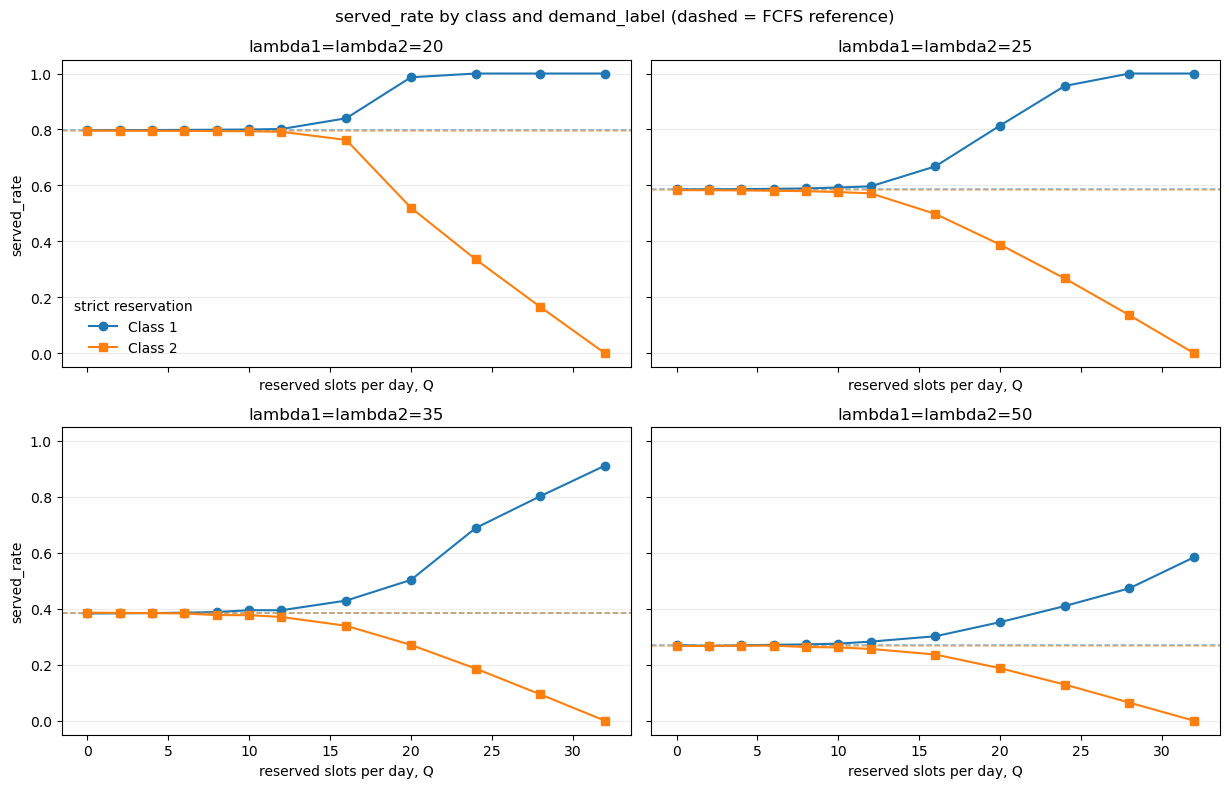

In [14]:
plot_class_metric_vs_q(
    "served_rate",
    scenario_type=PLOT_SCENARIO_TYPE,
    hue=PLOT_HUE,
)
plt.show()


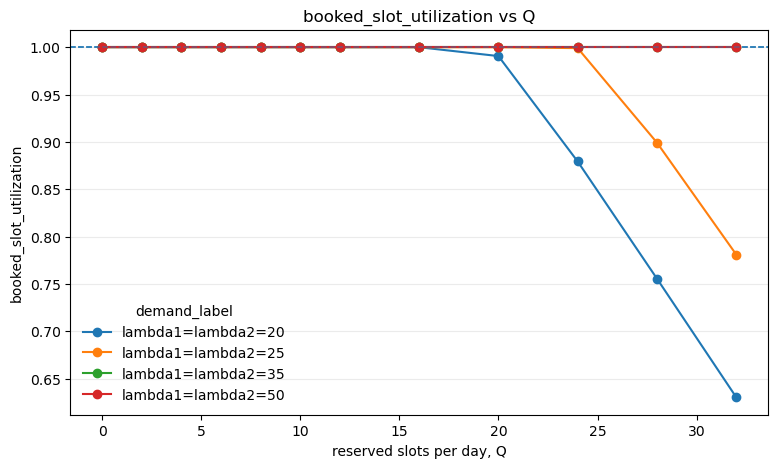

In [15]:
plot_metric_vs_q("booked_slot_utilization", scenario_type=PLOT_SCENARIO_TYPE, class_id=None, hue=PLOT_HUE)
plt.show()

In [16]:
plot_delta_heatmap(
    score_name=PLOT_SCORE_NAME,
    scenario_type=PLOT_SCENARIO_TYPE,
    class_1_weight=PLOT_CLASS_1_WEIGHT,
    slot_cost=PLOT_SLOT_COST,
    wait_penalty=PLOT_WAIT_PENALTY,
    rows=PLOT_HUE,
    columns="Q",
)
plt.show()

No rows for selected filters.


In [17]:
plot_best_q(
    score_name=PLOT_SCORE_NAME,
    scenario_type=PLOT_SCENARIO_TYPE,
    slot_cost=PLOT_SLOT_COST,
    wait_penalty=PLOT_WAIT_PENALTY,
    x=PLOT_HUE,
    hue="class_1_weight",
)
plt.show()

display(
    best_q[
        (best_q["score_name"] == PLOT_SCORE_NAME)
        & (best_q["scenario_type"] == PLOT_SCENARIO_TYPE)
        & (best_q["slot_cost"] == PLOT_SLOT_COST)
        & (best_q["wait_penalty"] == PLOT_WAIT_PENALTY)
    ].sort_values([PLOT_HUE, "class_1_weight"])
)

No rows for selected filters.


,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,Q,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification


## Slice And Export Data

Use this cell to make smaller tables for an email, document, or a custom plot.

In [18]:
selected_summary = apply_filters(
    difference_summary,
    score_name=PLOT_SCORE_NAME,
    scenario_type=PLOT_SCENARIO_TYPE,
    class_1_weight=PLOT_CLASS_1_WEIGHT,
    slot_cost=PLOT_SLOT_COST,
    wait_penalty=PLOT_WAIT_PENALTY,
)

display(selected_summary.sort_values(["demand_label", "Q"]))

# Uncomment to export a CSV.
# output_path = REPO_DIR / "notebooks" / "temp" / "selected_difference_summary.csv"
# output_path.parent.mkdir(parents=True, exist_ok=True)
# selected_summary.to_csv(output_path, index=False)
# print(output_path)

,scenario_id,scenario_type,demand_label,class_arrival_rate,lambda_1,lambda_2,lambda_total,class_1_share,Q,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification


## Optional Interactive Plot

If `ipywidgets` is installed, this gives a quick dropdown plotter. If widgets are not available, use the plain plotting cells above.

In [19]:
if HAS_WIDGETS:
    def interactive_delta(score_name, scenario_type, class_1_weight, slot_cost, wait_penalty):
        plot_delta_vs_q(
            score_name=score_name,
            scenario_type=scenario_type,
            class_1_weight=class_1_weight,
            slot_cost=slot_cost,
            wait_penalty=wait_penalty,
            hue="demand_label",
        )
        plt.show()

    widgets.interact(
        interactive_delta,
        score_name=sorted(score_df["score_name"].unique()),
        scenario_type=sorted(run_df["scenario_type"].unique()),
        class_1_weight=sorted(score_df["class_1_weight"].unique()),
        slot_cost=sorted(score_df["slot_cost"].unique()),
        wait_penalty=sorted(score_df["wait_penalty"].unique()),
    )
else:
    print("ipywidgets is not installed. Use the plain plotting helper cells above.")

interactive(children=(Dropdown(description='score_name', options=('booked_slot_utilization', 'net_booked_slot_…

## Scratch Area

Add your own experiments below this cell. Useful starting points:

```python
# Example: show only scenarios where the best Q is not zero.
best_q[best_q["Q"] > 0]

# Example: plot completed-slot utilization instead of booked-slot utilization.
plot_metric_vs_q("average_utilization", scenario_type="class_1_advantaged")

# Example: plot a class metric with Class 1 and Class 2 on the same axes.
plot_class_metric_vs_q("mean_offered_booking_delay", scenario_type="symmetric_baseline")

# Example: compare seed-level deltas at Q=12.
plot_seed_deltas(q=12, demand_label="lambda1=lambda2=25")
```
